# Ambiguity-gated retrieval bias — testing whether savings and content-match can be decoupled

Per Jasper's message (relayed via Claude web chat, 2026-07-18). The v2 rate-modulated savings
fix works but exposed a real tradeoff: settings that produce genuine savings (`k>=0.5`,
`w_fast_max>=10`) also degrade content-match (down to 13-40%, vs. 85-94% baseline). This tests
option (c) from the very first two-layer failure analysis, never tried until now: let strength
only break ties on genuinely ambiguous content, not override a clear content winner.

**Mechanism:**
```
similarities = X @ query                                  # raw content similarity, unchanged
gap = top1_similarity - top2_similarity                   # ambiguity measure
g = 1 / (1 + gap / gap_scale)                              # small gap -> g near 1 (strength active)
                                                            # large gap -> g near 0 (content dominates)
biased = beta * similarities + g * (log(w_fast) + char_weight * log(w_char))
```

`w_fast`/`w_char` update rules are **unchanged from v2** (headroom, capped multiplier, rate
modulation) — the gate only touches the retrieval-bias term. The point: savings is a property
of the update rule (doesn't need retrieval bias at all), content-match is a property of
retrieval — this is supposed to decouple them structurally, not just tune around the problem.

**Two outcomes, stated before running anything:**
- **(A) Gating decouples the two effects** — real savings preserved, content-match recovers
  close to the 85-94% baseline at the settings that previously tanked it. A genuinely good
  architectural result, validates "strength breaks ties, not clear mismatches."
- **(B) Content-match still degrades meaningfully even with gating** — the tradeoff is more
  fundamental than a retrieval-bias-shaping problem; no amount of ambiguity-gating recovers
  it. Also a real, useful negative result: would mean savings-via-rate-modulation and clean
  content-addressed retrieval aren't simultaneously achievable in this mechanism family.

Not tuning the gate function after seeing results to chase outcome (A) — `gap_scale` gets
swept honestly and reported as found.

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
torch.manual_seed(42)
n_patterns = 5
dim = 64

X = torch.randn(n_patterns, dim, device=device)
X = F.normalize(X, dim=1)

## Empirical gap distribution — grounding gap_scale choices in real data, not guesses

Sample many queries using the exact same generation scheme as every experiment in this
series (`normalize(X[idx] + noise*0.3)`), across all patterns, and look at the actual
top1-top2 similarity gap distribution before picking `gap_scale` sweep values.

In [3]:
torch.manual_seed(123)
gaps = []
for _ in range(2000):
    idx = torch.randint(0, n_patterns, (1,)).item()
    query = F.normalize(X[idx] + torch.randn(dim, device=device) * 0.3, dim=0)
    similarities = X @ query
    sorted_sims, _ = torch.sort(similarities, descending=True)
    gaps.append((sorted_sims[0] - sorted_sims[1]).item())

gaps = np.array(gaps)
print(f"Gap distribution: mean={gaps.mean():.4f}, median={np.median(gaps):.4f}, "
      f"std={gaps.std():.4f}, min={gaps.min():.4f}, max={gaps.max():.4f}")
print(f"Percentiles: 10%={np.percentile(gaps, 10):.4f}, 25%={np.percentile(gaps,25):.4f}, "
      f"75%={np.percentile(gaps,75):.4f}, 90%={np.percentile(gaps,90):.4f}")

Gap distribution: mean=0.2507, median=0.2557, std=0.1229, min=0.0007, max=0.6245
Percentiles: 10%=0.0794, 25%=0.1582, 75%=0.3429, 90%=0.4124


In [4]:
median_gap = np.median(gaps)
# span roughly an order of magnitude centered on the empirical median, not a blind guess
gap_scale_grid = [round(median_gap * 0.2, 4), round(median_gap * 0.6, 4),
                   round(median_gap * 2.0, 4), round(median_gap * 6.0, 4)]
print(f"Median gap = {median_gap:.4f}")
print(f"gap_scale sweep values: {gap_scale_grid}")

# sanity: what does g look like at the median gap for each gap_scale?
for gs in gap_scale_grid:
    g_at_median = 1 / (1 + median_gap / gs)
    print(f"  gap_scale={gs}: g at median gap = {g_at_median:.3f}")

Median gap = 0.2557
gap_scale sweep values: [np.float64(0.0511), np.float64(0.1534), np.float64(0.5115), np.float64(1.5344)]
  gap_scale=0.0511: g at median gap = 0.167
  gap_scale=0.1534: g at median gap = 0.375
  gap_scale=0.5115: g at median gap = 0.667
  gap_scale=1.5344: g at median gap = 0.857


In [5]:
decay_fast = 0.02
increment_fast = 0.1
decay_char = 0.0005
consolidation_rate = 0.01
char_weight = 1.0
w_char_max = 10.0
max_multiplier = 3.0

def make_update_fn(k, w_fast_max):
    def update_two_layer(w_fast, w_char, retrieval_weights):
        multiplier = (1 + k * (w_char - 1)).clamp(max=max_multiplier)
        increment_fast_effective = increment_fast * multiplier
        fast_headroom = (w_fast_max - w_fast).clamp(min=0) / w_fast_max
        w_fast = w_fast + decay_fast * (1 - w_fast) + increment_fast_effective * retrieval_weights * fast_headroom

        char_headroom = (w_char_max - w_char).clamp(min=0) / w_char_max
        w_char = w_char + decay_char * (1 - w_char) + consolidation_rate * (w_fast - 1).clamp(min=0) * char_headroom
        return w_fast, w_char
    return update_two_layer

def retrieve_gated(query, X, w_fast, w_char, gap_scale, beta=4.0):
    similarities = X @ query
    sorted_sims, _ = torch.sort(similarities, descending=True)
    gap = (sorted_sims[0] - sorted_sims[1]).item()
    g = 1 / (1 + gap / gap_scale)

    biased = beta * similarities + g * (torch.log(w_fast) + char_weight * torch.log(w_char))
    weights = F.softmax(biased, dim=0)
    retrieved = X.T @ weights
    return retrieved, weights, g

def run_gated_experiment(k, w_fast_max, gap_scale, phase_len, phase_patterns, seed=0, dominant_prob=0.7):
    update_two_layer = make_update_fn(k, w_fast_max)
    n_phases = len(phase_patterns)
    n_steps = phase_len * n_phases

    w_fast = torch.ones(n_patterns, device=device)
    w_char = torch.ones(n_patterns, device=device)
    fast_history = torch.zeros(n_steps, n_patterns)
    char_history = torch.zeros(n_steps, n_patterns)
    queried_idx_history = torch.zeros(n_steps, dtype=torch.long)
    won_idx_history = torch.zeros(n_steps, dtype=torch.long)
    g_history = torch.zeros(n_steps)

    minor_prob = (1 - dominant_prob) / (n_patterns - 1)

    torch.manual_seed(seed)
    for step in range(n_steps):
        phase = step // phase_len
        dom = phase_patterns[phase]
        probs = torch.full((n_patterns,), minor_prob)
        probs[dom] = dominant_prob

        idx = torch.multinomial(probs, 1).item()
        query = F.normalize(X[idx] + torch.randn(dim, device=device) * 0.3, dim=0)

        retrieved, retrieval_weights, g = retrieve_gated(query, X, w_fast, w_char, gap_scale, beta=4.0)
        w_fast, w_char = update_two_layer(w_fast, w_char, retrieval_weights)

        fast_history[step] = w_fast
        char_history[step] = w_char
        queried_idx_history[step] = idx
        won_idx_history[step] = retrieval_weights.argmax()
        g_history[step] = g

    phase_bounds = [i * phase_len for i in range(n_phases + 1)]
    return {"fast": fast_history, "char": char_history, "queried": queried_idx_history,
            "won": won_idx_history, "g": g_history, "phase_bounds": phase_bounds}

## Test at the settings that previously tanked content-match while producing genuine savings

From the v2 sweep: `(k=0.5, w_fast_max=10)`, `(k=1.0, w_fast_max=10)`, `(k=1.0, w_fast_max=20)`
were the three combinations with real savings AND degraded content-match (21-40%). Testing
gating across all three, across the full `gap_scale` grid.

In [6]:
def climb_stats(fast_history, pattern_idx, phase_start, phase_end):
    segment = fast_history[phase_start:phase_end, pattern_idx].numpy()
    x = np.arange(50)
    slope, _ = np.polyfit(x, segment[:50], 1)
    return slope

phase_patterns = [0, 1, 2, 0, 3]
test_points = [(0.5, 10.0), (1.0, 10.0), (1.0, 20.0)]

results = {}
for k, wfm in test_points:
    for gap_scale in gap_scale_grid:
        run = run_gated_experiment(k, wfm, gap_scale, phase_len=400, phase_patterns=phase_patterns, seed=0)
        results[(k, wfm, gap_scale)] = run

print(f"Ran {len(results)} gated combinations.")

Ran 12 gated combinations.


In [7]:
def content_match_rates(run, phase_patterns):
    pbl = run["phase_bounds"]
    rates = []
    for p, dom in enumerate(phase_patterns):
        lo, hi = pbl[p], pbl[p + 1]
        q = run["queried"][lo:hi]
        w = run["won"][lo:hi]
        rates.append((q == w).float().mean().item())
    return rates

print(f"{'k':>5} {'wfm':>5} {'gap_scale':>10} {'min_match%':>11} {'mean_g':>8} {'p1_slope':>9} {'p4_slope':>9} {'savings':>8}")
for k, wfm in test_points:
    for gap_scale in gap_scale_grid:
        run = results[(k, wfm, gap_scale)]
        pbl = run["phase_bounds"]
        rates = content_match_rates(run, phase_patterns)
        p1_slope = climb_stats(run["fast"], 0, pbl[0], pbl[1])
        p4_slope = climb_stats(run["fast"], 0, pbl[3], pbl[4])
        mean_g = run["g"].mean().item()
        savings = p4_slope > p1_slope
        print(f"{k:>5} {wfm:>5} {gap_scale:>10} {min(rates)*100:>10.1f}% {mean_g:>8.3f} "
              f"{p1_slope:>9.4f} {p4_slope:>9.4f} {str(savings):>8}")

    k   wfm  gap_scale  min_match%   mean_g  p1_slope  p4_slope  savings
  0.5  10.0     0.0511       95.5%    0.215    0.0257    0.0266     True
  0.5  10.0     0.1534       94.5%    0.421    0.0267    0.0286     True
  0.5  10.0     0.5115       83.0%    0.687    0.0282    0.0312     True
  0.5  10.0     1.5344       61.8%    0.862    0.0293    0.0325     True
  1.0  10.0     0.0511       95.5%    0.215    0.0271    0.0266    False
  1.0  10.0     0.1534       95.5%    0.421    0.0283    0.0287     True
  1.0  10.0     0.5115       89.0%    0.687    0.0300    0.0315     True
  1.0  10.0     1.5344       76.2%    0.862    0.0312    0.0334     True
  1.0  20.0     0.0511       95.7%    0.215    0.0305    0.0356     True
  1.0  20.0     0.1534       95.2%    0.421    0.0320    0.0386     True
  1.0  20.0     0.5115       83.5%    0.687    0.0341    0.0429     True
  1.0  20.0     1.5344       61.5%    0.862    0.0357    0.0460     True


## Reference: v2 (ungated) numbers at these same three points, for direct comparison

| k | w_fast_max | min content-match (v2, ungated) | savings (v2) |
|---|---|---|---|
| 0.5 | 10 | 40.3% | Yes (0.0302 -> 0.0321) |
| 1.0 | 10 | 54.3% | Yes (0.0321 -> 0.0343) |
| 1.0 | 20 | 37.7% | Yes (0.0369 -> 0.0474) |

## Sanity check — phase-2 transient shape, gated vs ungated (quick plot, not a full reseed check)

At `(k=0.5, w_fast_max=10)`, best-performing `gap_scale` from the table above vs. the v2
ungated equivalent, just confirming nothing structurally broke in the transient.

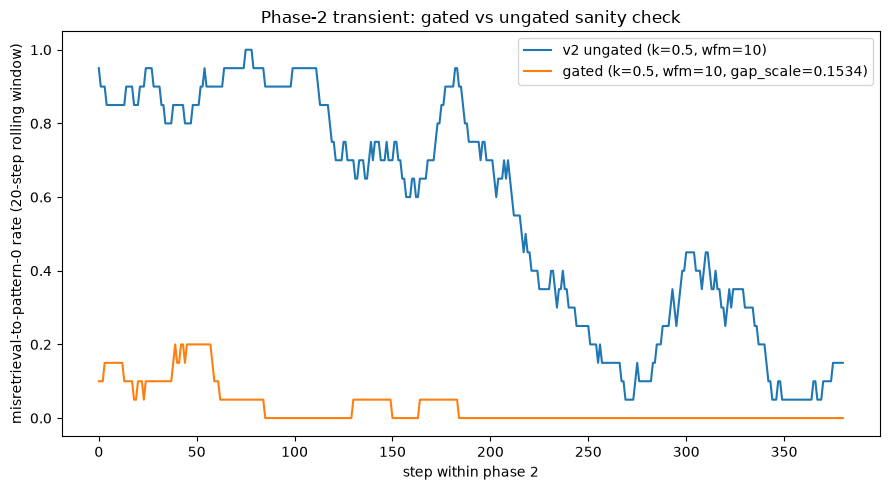

In [8]:
def windowed_misretrieval_rate(queried, won, phase_start, phase_end, window=20):
    q = queried[phase_start:phase_end].numpy()
    w = won[phase_start:phase_end].numpy()
    misretrieval = ((w == 0) & (q != 0)).astype(float)
    kernel = np.ones(window) / window
    return np.convolve(misretrieval, kernel, mode="valid")

update_fn_ungated = make_update_fn(0.5, 10.0)
run_ungated = run_two_layer_experiment_ungated = None  # placeholder, build inline below

def run_ungated_v2(k, w_fast_max, phase_len, phase_patterns, seed=0, dominant_prob=0.7):
    update_two_layer = make_update_fn(k, w_fast_max)
    n_phases = len(phase_patterns)
    n_steps = phase_len * n_phases
    w_fast = torch.ones(n_patterns, device=device)
    w_char = torch.ones(n_patterns, device=device)
    queried_idx_history = torch.zeros(n_steps, dtype=torch.long)
    won_idx_history = torch.zeros(n_steps, dtype=torch.long)
    minor_prob = (1 - dominant_prob) / (n_patterns - 1)
    torch.manual_seed(seed)
    for step in range(n_steps):
        phase = step // phase_len
        dom = phase_patterns[phase]
        probs = torch.full((n_patterns,), minor_prob)
        probs[dom] = dominant_prob
        idx = torch.multinomial(probs, 1).item()
        query = F.normalize(X[idx] + torch.randn(dim, device=device) * 0.3, dim=0)
        similarities = X @ query
        biased = 4.0 * similarities + torch.log(w_fast) + char_weight * torch.log(w_char)
        retrieval_weights = F.softmax(biased, dim=0)
        w_fast, w_char = update_two_layer(w_fast, w_char, retrieval_weights)
        queried_idx_history[step] = idx
        won_idx_history[step] = retrieval_weights.argmax()
    phase_bounds = [i * phase_len for i in range(n_phases + 1)]
    return {"queried": queried_idx_history, "won": won_idx_history, "phase_bounds": phase_bounds}

run_ungated = run_ungated_v2(0.5, 10.0, 400, phase_patterns, seed=0)
best_gap_scale = gap_scale_grid[1]  # will inspect table above to sanity check this is reasonable
run_gated_best = results[(0.5, 10.0, best_gap_scale)]

pbl = run_ungated["phase_bounds"]
rate_ungated = windowed_misretrieval_rate(run_ungated["queried"], run_ungated["won"], pbl[1], pbl[2])
rate_gated = windowed_misretrieval_rate(run_gated_best["queried"], run_gated_best["won"], pbl[1], pbl[2])

plt.figure(figsize=(9, 5))
plt.plot(rate_ungated, label="v2 ungated (k=0.5, wfm=10)")
plt.plot(rate_gated, label=f"gated (k=0.5, wfm=10, gap_scale={best_gap_scale})")
plt.xlabel("step within phase 2")
plt.ylabel("misretrieval-to-pattern-0 rate (20-step rolling window)")
plt.title("Phase-2 transient: gated vs ungated sanity check")
plt.legend()
plt.tight_layout()
plt.savefig("gated_transient_check.png", dpi=100)
plt.show()